# Jane Street Real-Time Market Data Forecasting

## LightGBM Baseline with Strict Forward-Looking Validation

This notebook develops a research-oriented LightGBM baseline for short-horizon prediction of `responder_6` on the Jane Street real-time market dataset.

The notebook focuses on robust short-horizon financial prediction under realistic forward-looking validation constraints.

The workflow focuses on several practical challenges commonly encountered in financial prediction problems:

- non-stationary time-series structure
- weak-signal detection
- leakage prevention
- temporal validation stability
- robustness under harder out-of-sample regimes

The implementation uses chronological train/validation splits, weighted evaluation aligned with the competition metric, conservative feature handling, and multiple robustness diagnostics designed to reduce overly optimistic validation estimates.

## Summary of Results

- Original dataset size: ~25 million rows
- Validation weighted R²: ~0.0087
- Harder 60/40 split weighted R²: ~0.0031
- Shuffle-target weighted R²: ~-0.0012

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [2]:
file_path = "data/df_concat_6_9.parquet"
df = pd.read_parquet(file_path)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 24,954,072 rows, 92 columns


,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,...,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
0,1020,0,0,2.679878,-0.151614,-1.218194,-0.584913,-0.129442,1.564324,0.367270,...,-0.315150,0.057490,-0.020380,0.151817,1.176065,-0.683896,1.222135,1.822080,-0.699136,2.865153
1,1020,0,1,4.407496,-0.114243,-1.553200,-0.438179,0.147782,1.686174,0.283562,...,-0.328378,-0.214946,-0.036094,-0.036046,0.525263,-0.434739,1.235148,0.914796,-0.717382,0.643339
2,1020,0,2,2.821721,-0.563401,-1.109032,-0.146964,-0.112394,1.528836,0.460348,...,-0.150332,-0.441242,-0.281995,0.155182,-1.106123,-0.771560,-0.464858,-0.793521,-0.717857,-1.547887
3,1020,0,3,1.700922,-0.499214,-0.807310,0.037185,0.256615,1.996381,0.208247,...,1.049820,0.246010,0.362785,0.000741,0.304133,-0.598776,0.545253,0.198089,-1.289874,0.688991
4,1020,0,4,2.232697,0.271390,-1.067931,-0.073194,0.355548,1.794548,0.136368,...,0.725878,-0.473040,-0.140053,-1.146351,0.145259,-0.030338,-1.370866,0.328847,0.035067,-1.773254


The dataset is expected to contain:

- `date_id` for temporal ordering
- `symbol_id` for asset identity
- `weight` for weighted training/evaluation
- `responder_6` as the target
- anonymized predictive features

## 2. Basic checks

In [3]:
required_cols = ["date_id", "weight", "responder_6"]

missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Required columns found.")
print("Min date_id:", df["date_id"].min())
print("Max date_id:", df["date_id"].max())
print("Unique dates :", df["date_id"].nunique())

Required columns found.
Min date_id: 1020
Max date_id: 1698
Unique dates : 679


## 3. Missing values overview

In [4]:
missing_ratio = df.isna().mean().sort_values(ascending=False)

print("Top 20 columns with highest missing ratio:")
display(missing_ratio.head(20))

Top 20 columns with highest missing ratio:


feature_42    0.070248
feature_39    0.070248
feature_53    0.070248
feature_50    0.070248
feature_15    0.024793
feature_44    0.018595
feature_41    0.018595
feature_52    0.018595
feature_55    0.018595
feature_08    0.011249
feature_73    0.009920
feature_74    0.009920
feature_33    0.009825
feature_58    0.009825
feature_32    0.009825
feature_31    0.004267
feature_26    0.004267
feature_21    0.004267
feature_27    0.004267
feature_17    0.004132
dtype: float64

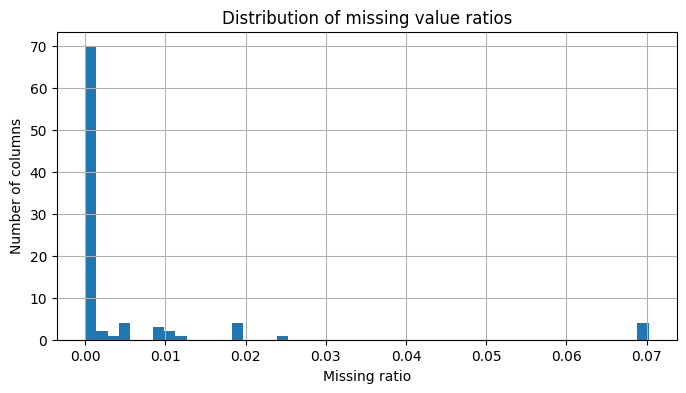

In [5]:
plt.figure(figsize=(8, 4))
missing_ratio.hist(bins=50)
plt.title("Distribution of missing value ratios")
plt.xlabel("Missing ratio")
plt.ylabel("Number of columns")
plt.show()

The target exhibits noisy, heavy-tailed behavior and unstable cumulative dynamics over time.  
This supports the use of strict chronological validation rather than random train/test splits.

Missing values are handled natively by LightGBM.

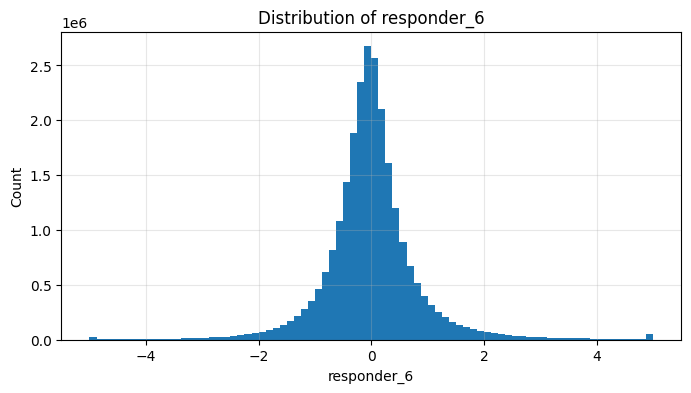

In [26]:
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 4))
plt.hist(target_sample[target_col].clip(-5, 5), bins=80)
plt.title("Distribution of responder_6")
plt.xlabel("responder_6")
plt.ylabel("Count")
plt.grid(alpha=0.3)

plt.savefig(
    "figures/responder6_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

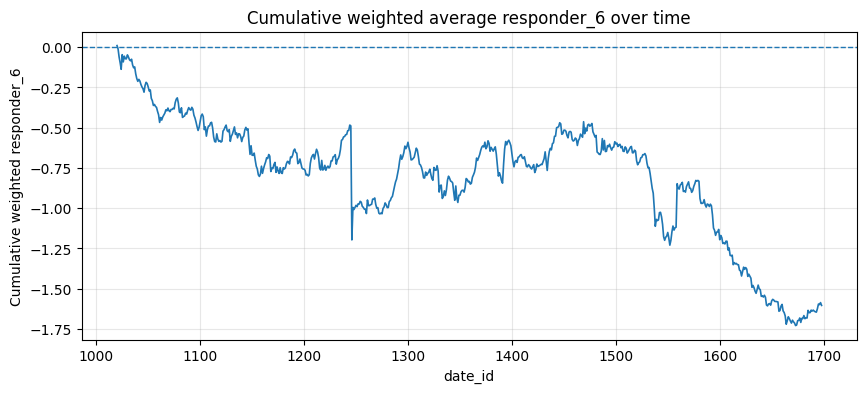

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(daily_target.index, daily_target.cumsum(), linewidth=1.2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative weighted average responder_6 over time")
plt.xlabel("date_id")
plt.ylabel("Cumulative weighted responder_6")
plt.grid(alpha=0.3)

plt.savefig(
    "figures/cumulative_responder6.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## 4. Define target, weights, and feature set



In [6]:
target_col = "responder_6"
weight_col = "weight"
time_col = "date_id"

other_responder_cols = [
    c for c in df.columns
    if c.startswith("responder_") and c != target_col
]

excluded_cols = [target_col, weight_col, time_col] + other_responder_cols

feature_cols = [c for c in df.columns if c not in excluded_cols]

print("symbol_id in feature_cols:", "symbol_id" in feature_cols)
print("Features BEFORE filtering:", len(feature_cols))

missing_ratio = df[feature_cols].isna().mean()

feature_cols = missing_ratio[missing_ratio < 0.8].index.tolist()

print("Features AFTER filtering:", len(feature_cols))
print(feature_cols[:20])

symbol_id in feature_cols: True
Features BEFORE filtering: 81
Features AFTER filtering: 81
['time_id', 'symbol_id', 'feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17']


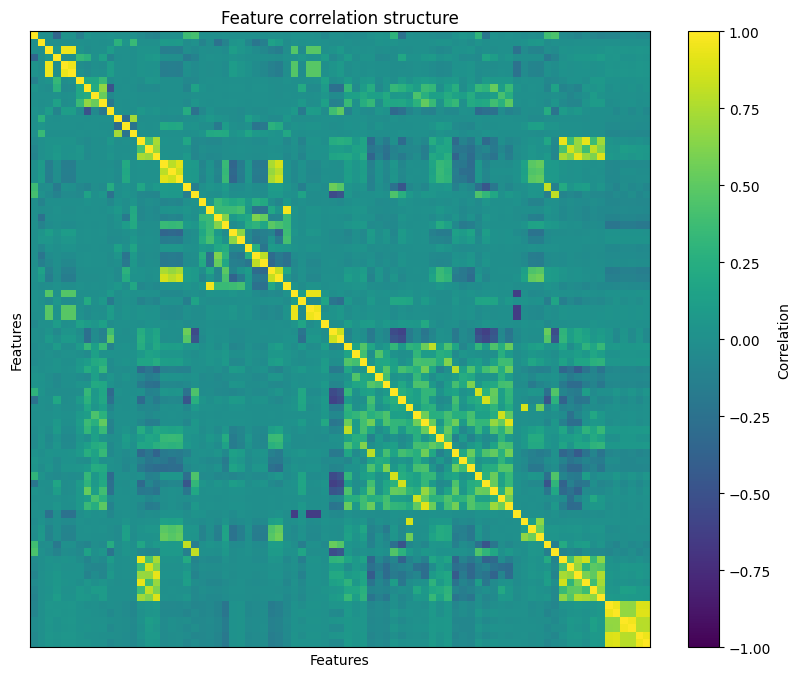

In [23]:
# Feature correlation structure on a small temporal sample

corr_sample = df[feature_cols].sample(
    n=min(100_000, len(df)),
    random_state=42
)

corr_matrix = corr_sample.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Feature correlation structure")
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks([])
plt.yticks([])
plt.show()

The feature correlation matrix suggests the presence of latent feature groups rather than fully independent predictors.  
This is consistent with anonymized market features that may encode related signals or shared risk factors.

Feature set excludes:
- date_id
- weight
- non-target responder_* columns

In [ ]:
# Sparse temporal sampling to reduce local training cost
# while preserving exposure to multiple market regimes

unique_dates = np.sort(df[time_col].unique())

sampled_dates = unique_dates[::20]

df_model = df[df[time_col].isin(sampled_dates)].copy()

print(f"Rows used: {df_model.shape[0]:,}")
print(f"Dates used: {df_model[time_col].nunique()}")
print(f"Fraction used: {df_model.shape[0] / df.shape[0]:.4f}")

Rows used: 1,240,008
Dates used: 34
Fraction used: 0.0497


Temporal subsampling is used to reduce local training cost while preserving multiple market regimes.

## 6. Strict forward-looking train/validation split

Strict forward-looking split:
- training: earlier dates
- validation: later dates

In [8]:
unique_dates_model = np.sort(df_model[time_col].unique())

train_fraction = 0.8
cutoff_idx = int(train_fraction * len(unique_dates_model))
cutoff_date = unique_dates_model[cutoff_idx]

train_mask = df_model[time_col] < cutoff_date
valid_mask = df_model[time_col] >= cutoff_date

train_df = df_model.loc[train_mask].copy()
valid_df = df_model.loc[valid_mask].copy()

print(f"Cutoff date_id: {cutoff_date}")
print(f"Train rows: {train_df.shape[0]:,}")
print(f"Valid rows: {valid_df.shape[0]:,}")
print(f"Train dates: {train_df[time_col].nunique()}")
print(f"Valid dates: {valid_df[time_col].nunique()}")

Cutoff date_id: 1560
Train rows: 991,232
Valid rows: 248,776
Train dates: 27
Valid dates: 7


## 7. Build train and validation matrices

In [9]:
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col]
w_train = train_df[weight_col]

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[target_col]
w_valid = valid_df[weight_col]

# Light clipping for fat-tailed financial features
clip_value = 5

X_train = X_train.clip(-clip_value, clip_value)
X_valid = X_valid.clip(-clip_value, clip_value)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (991232, 81)
X_valid: (248776, 81)


In [10]:
print("Missing values in X_train:", int(X_train.isna().sum().sum()))
print("Missing values in X_valid:", int(X_valid.isna().sum().sum()))

Missing values in X_train: 442539
Missing values in X_valid: 124562


## 8. Competition-aligned metric: weighted zero-mean R²

In [11]:
def weighted_r2_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)

    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true ** 2))

    if denominator == 0:
        return 0.0

    return 1.0 - numerator / denominator


def lgb_weighted_r2(preds, dataset):
    y_true = dataset.get_label()
    weights = dataset.get_weight()
    score = weighted_r2_score(y_true, preds, weights)
    return "weighted_r2", score, True

Primary evaluation metric: weighted zero-mean R².

## 9. LightGBM datasets

In [12]:
categorical_features = []
if "symbol_id" in X_train.columns:
    categorical_features = ["symbol_id"]

train_data = lgb.Dataset(
    X_train,
    label=y_train,
    weight=w_train,
    categorical_feature=categorical_features,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    weight=w_valid,
    reference=train_data,
    categorical_feature=categorical_features,
    free_raw_data=False
)

print("LightGBM datasets created.")
print("Categorical features:", categorical_features)
print("symbol_id used as categorical:", categorical_features)

LightGBM datasets created.
Categorical features: ['symbol_id']
symbol_id used as categorical: ['symbol_id']


## 10. Train baseline LightGBM model

In [13]:
params = {
    "objective": "regression",
    "metric": "None",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 128,
    "max_depth": -1,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 2.0,
    "verbosity": -1,
    "seed": 42,
}

In [14]:
model = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    feval=lgb_weighted_r2,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	train's weighted_r2: 0.11698	valid's weighted_r2: 0.00621493
Early stopping, best iteration is:
[51]	train's weighted_r2: 0.0699194	valid's weighted_r2: 0.00868104


## 11. Validation performance

In [15]:
y_pred = model.predict(X_valid, num_iteration=model.best_iteration)

weighted_r2 = weighted_r2_score(y_valid.values, y_pred, w_valid.values)
weighted_rmse = np.sqrt(mean_squared_error(y_valid, y_pred, sample_weight=w_valid))

print(f"Best iteration : {model.best_iteration}")
print(f"Weighted R²    : {weighted_r2:.6f}")
print(f"Weighted RMSE  : {weighted_rmse:.6f}")

Best iteration : 51
Weighted R²    : 0.008681
Weighted RMSE  : 0.835765


Weighted R² is reported alongside weighted RMSE for reference.

## 12. Feature importance

In [16]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance_gain": model.feature_importance(importance_type="gain"),
    "importance_split": model.feature_importance(importance_type="split")
}).sort_values("importance_gain", ascending=False)

display(feature_importance.head(20))

,feature,importance_gain,importance_split
22,feature_20,54432.254890,249
10,feature_08,52227.211990,195
25,feature_23,51378.533493,218
26,feature_24,49278.951759,213
31,feature_29,47862.526360,204
9,feature_07,45772.049339,168
3,feature_01,42398.934891,177
38,feature_36,38719.313210,131
8,feature_06,37723.390877,86
63,feature_61,37647.929054,140


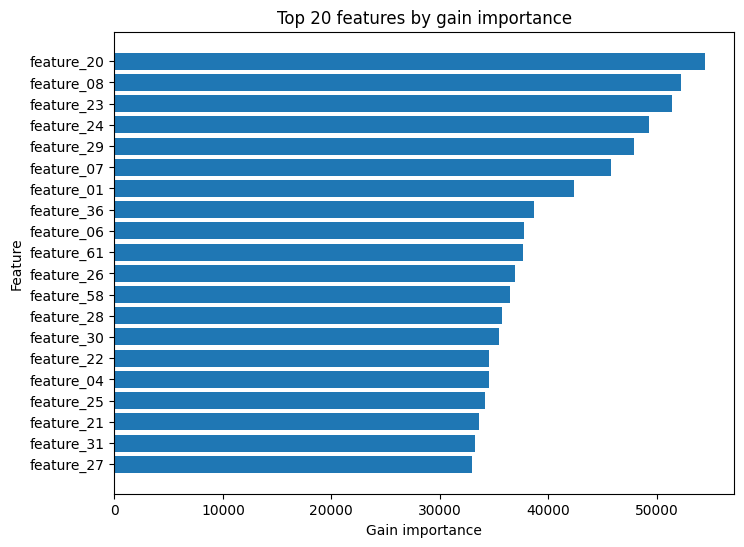

In [17]:
top_n = 20
fi_plot = feature_importance.head(top_n).sort_values("importance_gain", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(fi_plot["feature"], fi_plot["importance_gain"])
plt.title(f"Top {top_n} features by gain importance")
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.show()

Gain-based importance is useful for exploration, but may not reflect stable predictive value across time.

## 13. Save model and artifacts

In [18]:
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

model_path = "models/lgbm_janestreet_baseline.txt"
fi_path = "artifacts/feature_importance_baseline.csv"

model.save_model(model_path)
feature_importance.to_csv(fi_path, index=False)

print("Saved model to:", model_path)
print("Saved feature importance to:", fi_path)

Saved model to: models/lgbm_janestreet_baseline.txt
Saved feature importance to: artifacts/feature_importance_baseline.csv


In [21]:
# Additional validation checks

print("Additional validation checks")

train_pred = model.predict(X_train, num_iteration=model.best_iteration)
valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)

train_score = weighted_r2_score(y_train.values, train_pred, w_train.values)
valid_score = weighted_r2_score(y_valid.values, valid_pred, w_valid.values)
ratio = train_score / valid_score if abs(valid_score) > 1e-12 else np.nan

print("\nTrain / validation gap")
print(f"train weighted R² : {train_score:.6f}")
print(f"valid weighted R² : {valid_score:.6f}")
print(f"train/valid ratio : {ratio:.3f}")

# Harder OOS split: train on first 60% of sampled dates, validate on last 40%
unique_dates_model = np.sort(df_model[time_col].unique())
cutoff_date_60 = unique_dates_model[int(0.6 * len(unique_dates_model))]

train_df_60 = df_model[df_model[time_col] < cutoff_date_60].copy()
valid_df_60 = df_model[df_model[time_col] >= cutoff_date_60].copy()

X_train_60 = train_df_60[feature_cols].clip(-clip_value, clip_value)
X_valid_60 = valid_df_60[feature_cols].clip(-clip_value, clip_value)

train_data_60 = lgb.Dataset(
    X_train_60,
    label=train_df_60[target_col],
    weight=train_df_60[weight_col],
    categorical_feature=categorical_features,
    free_raw_data=False
)

valid_data_60 = lgb.Dataset(
    X_valid_60,
    label=valid_df_60[target_col],
    weight=valid_df_60[weight_col],
    categorical_feature=categorical_features,
    free_raw_data=False
)

model_60 = lgb.train(
    params=params,
    train_set=train_data_60,
    num_boost_round=2000,
    valid_sets=[valid_data_60],
    valid_names=["valid_60"],
    feval=lgb_weighted_r2,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(0)
    ]
)

pred_60 = model_60.predict(X_valid_60, num_iteration=model_60.best_iteration)

score_60 = weighted_r2_score(
    valid_df_60[target_col].values,
    pred_60,
    valid_df_60[weight_col].values
)

print("\nHarder out-of-sample split")
print(f"60/40 weighted R² : {score_60:.6f}")

# Shuffle-target sanity check
rng = np.random.default_rng(42)
y_train_shuffled = rng.permutation(y_train.values)

train_data_fake = lgb.Dataset(
    X_train,
    label=y_train_shuffled,
    weight=w_train,
    categorical_feature=categorical_features,
    free_raw_data=False
)

model_fake = lgb.train(
    params=params,
    train_set=train_data_fake,
    num_boost_round=300,
    valid_sets=[valid_data],
    valid_names=["valid_fake"],
    feval=lgb_weighted_r2,
    callbacks=[lgb.log_evaluation(0)]
)

pred_fake = model_fake.predict(X_valid, num_iteration=model_fake.best_iteration)

score_fake = weighted_r2_score(
    y_valid.values,
    pred_fake,
    w_valid.values
)

print("\nShuffle-target sanity check")
print(f"shuffle-target weighted R² : {score_fake:.6f}")

Additional validation checks

Train / validation gap
train weighted R² : 0.069919
valid weighted R² : 0.008681
train/valid ratio : 8.054
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[18]	valid_60's weighted_r2: 0.0030691

Harder out-of-sample split
60/40 weighted R² : 0.003069

Shuffle-target sanity check
shuffle-target weighted R² : -0.001232


## Research observations

Several empirical patterns are consistent with short-horizon financial prediction:

- The target is noisy, weakly predictable, and unstable over time.
- The stricter 60/40 out-of-sample split leads to a lower weighted R², suggesting non-stationarity.
- The train/validation gap confirms that overfitting is a serious risk even with regularized tree models.
- The shuffle-target experiment produces near-zero/negative R², which supports the absence of obvious target leakage.
- Feature correlations suggest latent structure among anonymized predictors, motivating future work on feature clustering and regime-aware validation.

Overall, the goal of this notebook is not to maximize leaderboard performance, but to build a leakage-aware and research-oriented baseline under realistic temporal validation constraints.